=== raw parquet info ===
(1242460, 7)
['date', 'value', 'model', 'scenario', 'variable', 'year', 'month']
        date      value    model    scenario variable  year  month
0 2000-01-01  20.026772  BNU-ESM  historical    tmean  2000      1
1 2000-01-02  15.063664  BNU-ESM  historical    tmean  2000      1
2 2000-01-03  11.760889  BNU-ESM  historical    tmean  2000      1
3 2000-01-04  10.990831  BNU-ESM  historical    tmean  2000      1
4 2000-01-05  11.841302  BNU-ESM  historical    tmean  2000      1

=== cleaned df info ===
(1063610, 7)
           date  year    scenario    model      value
1460 2004-01-01  2004  historical  BNU-ESM  13.847445
1461 2004-01-02  2004  historical  BNU-ESM  14.117373
1462 2004-01-03  2004  historical  BNU-ESM  14.266186
1463 2004-01-04  2004  historical  BNU-ESM  14.406878
1464 2004-01-05  2004  historical  BNU-ESM  14.967586

=== daily GDD check ===
           date      value  gdd_daily
1460 2004-01-01  13.847445   4.447445
1461 2004-01-02  14.117373   

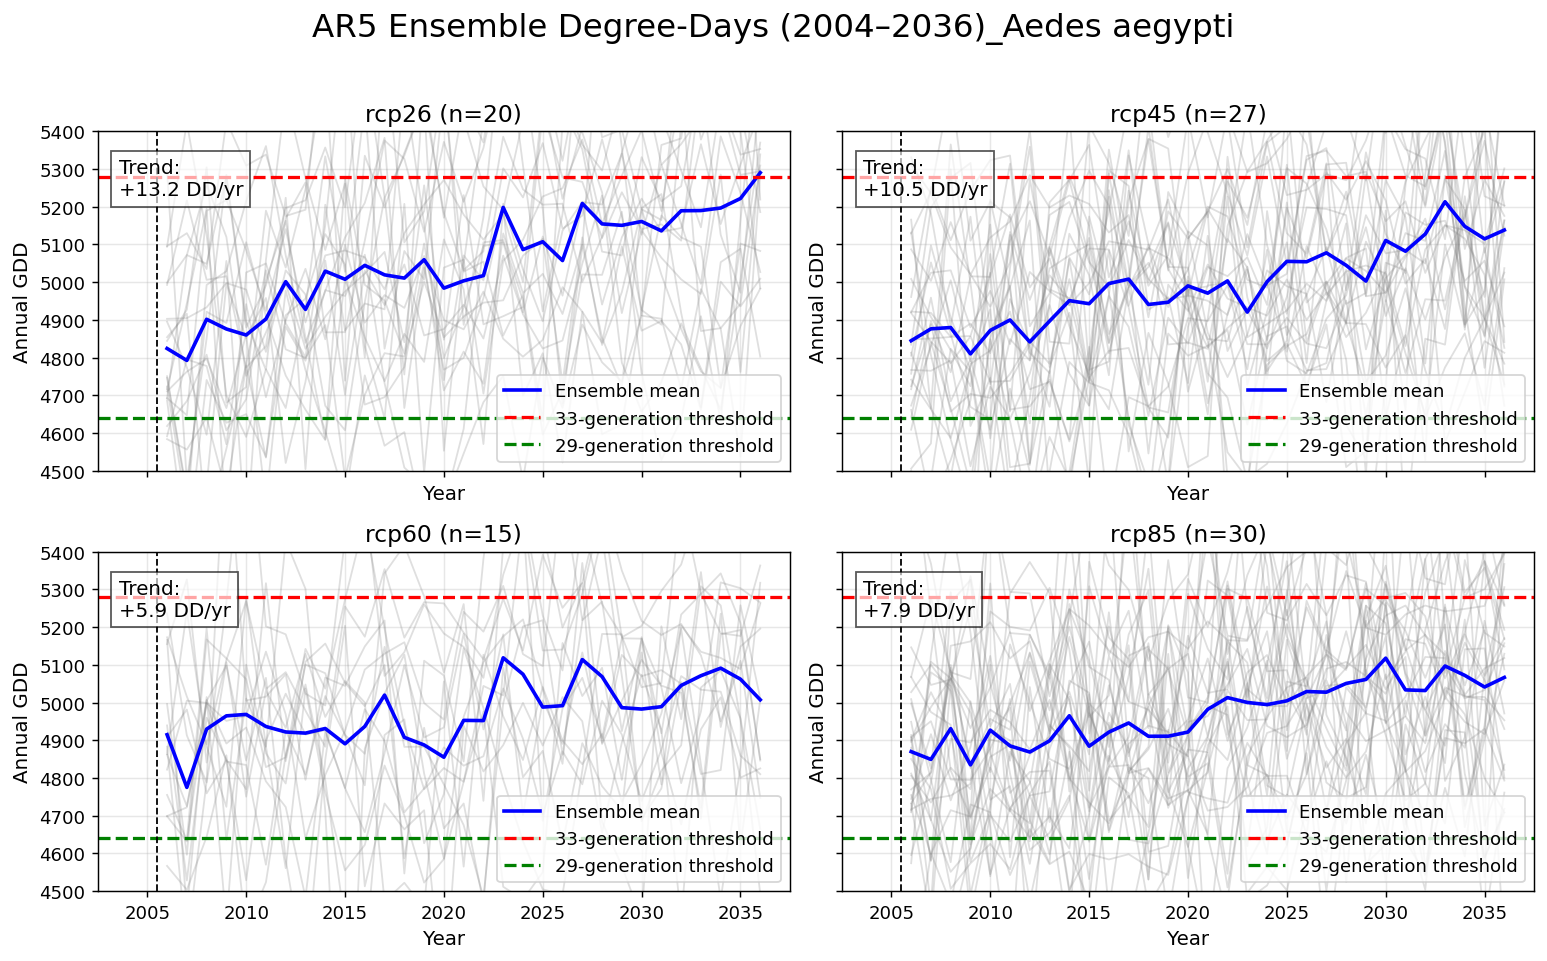

In [24]:
# =========================
# 0. 套件
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pathlib import Path
import sys
np.set_printoptions(threshold=sys.maxsize)
# 輸出資料夾
output_dir = Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue")#"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue"
output_dir.mkdir(parents=True, exist_ok=True)
# -------------------------
# matplotlib 基本設定
# -------------------------
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 1. 參數設定
# =========================
FILE_PATH = r"C:\Users\user\Climate_project\程式作業\Daxue＿village\qm_corrected_output\tmean_corrected_daily_final_models.parquet"

START_YEAR = 2004
END_YEAR = 2036

# Degree-day 參數
BASE_TEMP = 9.4        # 發育下限溫度 Tb
DD_PER_GENERATION = 160 # 每世代所需 DD

# 世代門檻線
DD_4GEN = 29 * DD_PER_GENERATION   # 2600
DD_5GEN = 33 * DD_PER_GENERATION   # 3250

# 情境順序
SCENARIO_ORDER = ["rcp26", "rcp45", "rcp60", "rcp85"]

# 分隔 historical / future 的參考線
REFERENCE_YEAR = 2005.5   # 跟你現在圖上風格接近


# =========================
# 2. 讀資料
# =========================
fp = Path(FILE_PATH)
if not fp.exists():
    raise FileNotFoundError(f"找不到檔案：{FILE_PATH}")

df = pd.read_parquet(fp)

print("=== raw parquet info ===")
print(df.shape)
print(df.columns.tolist())
print(df.head())


# =========================
# 3. 基本整理
# =========================
# 日期
df["date"] = pd.to_datetime(df["date"])

# 年
df["year"] = df["date"].dt.year

# 篩年份
df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)].copy()

# scenario 小寫統一
df["scenario"] = df["scenario"].astype(str).str.lower()

# model 字串
df["model"] = df["model"].astype(str)

# value 轉數值
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# 去缺值
df = df.dropna(subset=["date", "value", "model", "scenario"]).copy()
# ✅ 放在這裡（關鍵位置）
df = df.drop_duplicates(subset=["scenario", "model", "date"]).copy()


print("\n=== cleaned df info ===")
print(df.shape)
print(df[["date", "year", "scenario", "model", "value"]].head())


# =========================
# 4. 計算每日 GDD
# =========================
# 這裡依你目前設定，用 Tmax 直接減 Tb
# 如果你之後想改成 Tmean，更符合一般 GDD 方法，再跟我說
df["gdd_daily"] = (df["value"] - BASE_TEMP).clip(lower=0)

print("\n=== daily GDD check ===")
print(df[["date", "value", "gdd_daily"]].head())


# =========================
# 5. 算每個 model / scenario / year 的 annual GDD
# =========================
annual_gdd = (
    df.groupby(["scenario", "model", "year"], as_index=False)["gdd_daily"]
      .sum()
      .rename(columns={"gdd_daily": "annual_gdd"})
)

print("\n=== annual_gdd ===")
print(annual_gdd.head())
print(annual_gdd.shape)


# =========================
# 6. 計算 ensemble mean 與趨勢
# =========================
ensemble_mean = (
    annual_gdd.groupby(["scenario", "year"], as_index=False)["annual_gdd"]
              .mean()
              .rename(columns={"annual_gdd": "ensemble_mean_gdd"})
)

scenario_counts = (
    annual_gdd.groupby("scenario")["model"]
              .nunique()
              .reindex(SCENARIO_ORDER)
)

print("\n=== ensemble mean ===")
print(ensemble_mean.to_string())#print(df.to_string())

print("\n=== scenario model counts ===")
print(scenario_counts.head())


# =========================
# 7. 畫圖
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharex=True, sharey=True)
axes = axes.flatten()

for ax, scenario in zip(axes, SCENARIO_ORDER):
    sub = annual_gdd[annual_gdd["scenario"] == scenario].copy()
    sub_mean = ensemble_mean[ensemble_mean["scenario"] == scenario].copy()
    #print(sub_mean)
    if sub.empty:
        ax.set_visible(False)
        continue

    # ---- 灰線：每個 model ----
    for model_name, g in sub.groupby("model"):
        g = g.sort_values("year")
        ax.plot(
            g["year"],
            g["annual_gdd"],
            color="gray",
            alpha=0.25,
            linewidth=1
        )

    # ---- 藍線：ensemble mean ----
    sub_mean = sub_mean.sort_values("year")
    ax.plot(
        sub_mean["year"],
        sub_mean["ensemble_mean_gdd"],
        color="blue",
        linewidth=2,
        label="Ensemble mean"
    )

    # ---- 水平門檻線 ----
    ax.axhline(
        DD_5GEN,
        color="red",
        linestyle="--",
        linewidth=1.8,
        label="33-generation threshold"
    )
    ax.axhline(
        DD_4GEN,
        color="green",
        linestyle="--",
        linewidth=1.8,
        label="29-generation threshold"
    )

    # ---- 垂直參考線 ----
    ax.axvline(
        REFERENCE_YEAR,
        color="black",
        linestyle="--",
        linewidth=1
    )

    # ---- 線性趨勢（ensemble mean）----
    if len(sub_mean) >= 2:
        slope, intercept = np.polyfit(sub_mean["year"], sub_mean["ensemble_mean_gdd"], 1)
        trend_text = f"Trend:\n+{slope:.1f} DD/yr" if slope >= 0 else f"Trend:\n{slope:.1f} DD/yr"
    else:
        slope = np.nan
        trend_text = "Trend:\nN/A"

    ax.text(
        0.03, 0.92,
        trend_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.65)
    )

    # ---- 標題 ----
    n_models = scenario_counts.get(scenario, np.nan)
    ax.set_title(f"{scenario} (n={int(n_models)})", fontsize=13)

    # ---- 座標與格線 ----
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Annual GDD", fontsize=11)
    ax.set_ylim([|45|00,5400])
    ax.grid(True, alpha=0.3)

    # ---- 圖例 ----
    ax.legend(loc="lower right", fontsize=10)

# 總標題
fig.suptitle("AR5 Ensemble Degree-Days (2004–2036)_Aedes aegypti", fontsize=18, y=0.98)

# x/y 範圍可依需要微調
for ax in axes:
    if ax.get_visible():
        ax.set_xlim(2002.5, 2037.5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
outpath = output_dir / f"AR5 Ensemble correct Degree-Days (2004–2036)_Aedes aegypti.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
Aedes aegypti
dd 160
his 4800.53
rcp26 5196.70
rcp45 5147.93
rcp60 5091.18
rcp85 5072.01

Aedes albopictus
dd 190
his 5965.80
rcp26 6357.73
rcp45 6309.96
rcp60 6254.88
rcp85 6233.94

   scenario  year  ensemble_mean_gen
2     rcp26  2006          30.151819
3     rcp26  2007          29.953927
4     rcp26  2008          30.635617
5     rcp26  2009          30.474683
6     rcp26  2010          30.375060
7     rcp26  2011          30.640304
8     rcp26  2012          31.259258
9     rcp26  2013          30.799216
10    rcp26  2014          31.433135
11    rcp26  2015          31.298912
12    rcp26  2016          31.529136
13    rcp26  2017          31.371734
14    rcp26  2018          31.317956
15    rcp26  2019          31.622527
16    rcp26  2020          31.151570
17    rcp26  2021          31.272913
18    rcp26  2022          31.359158
19    rcp26  2023          32.488865
20    rcp26  2024          31.790553
21    rcp26  2025          31.920660
22    rcp26  2026          31.608527
23    rcp26  2027          32.554702
24    rcp26  2028          32.215974
25    rcp26  2029          32.192021
26    rcp26  2030          32.256238
27    rcp26  2031          32.100550
2

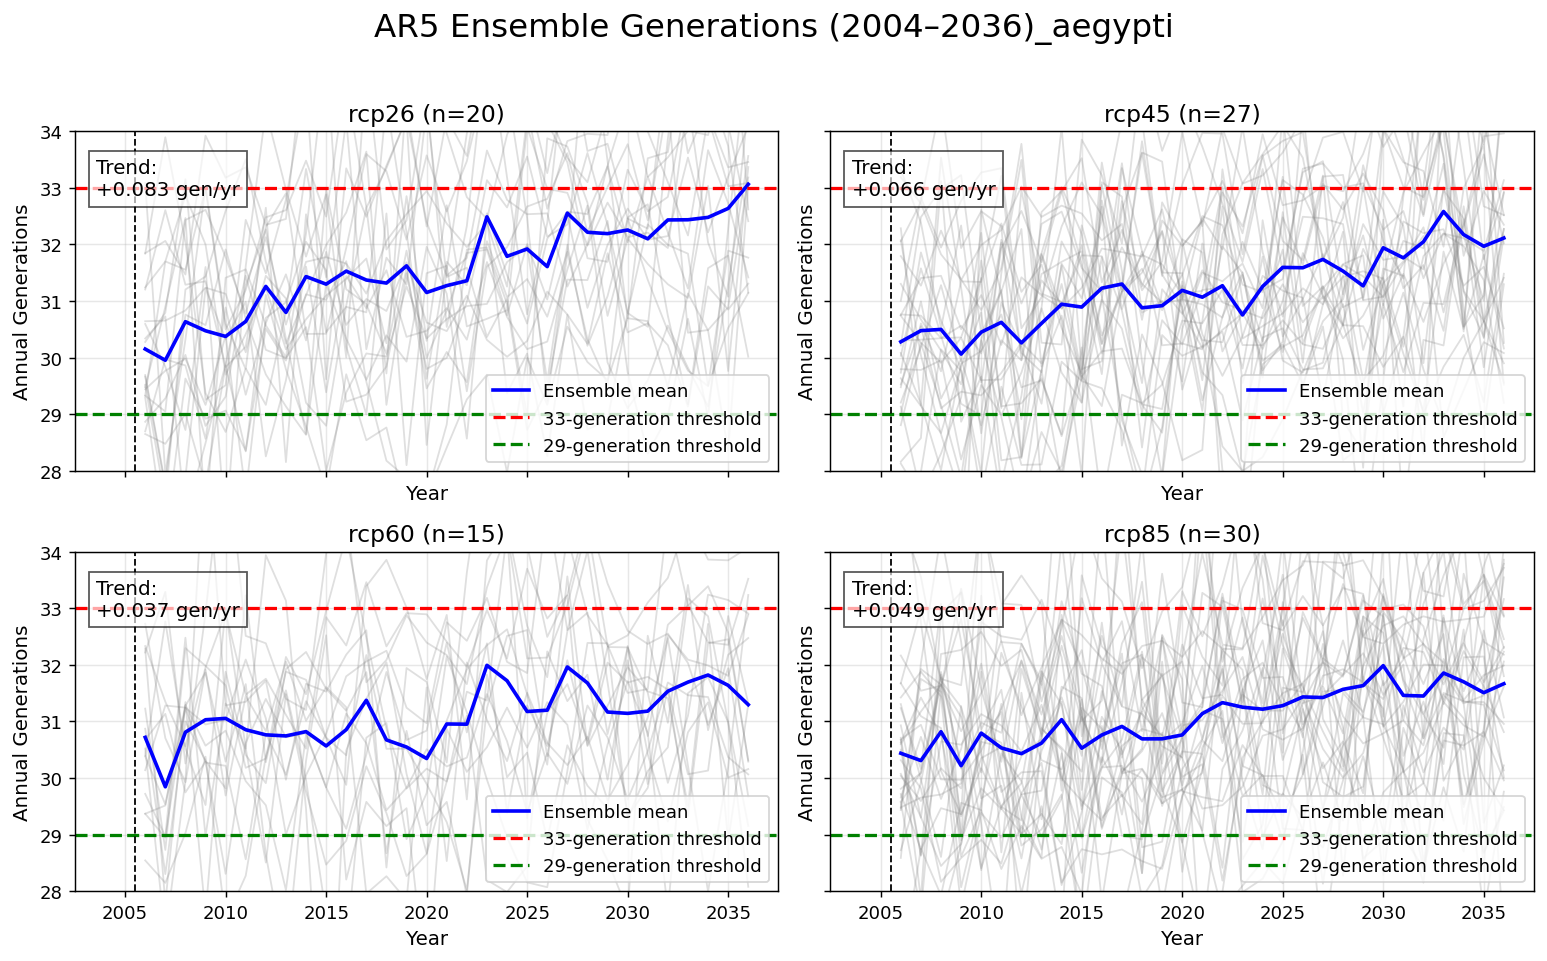

In [27]:
# =========================
# 8. 計算世代數
# =========================
annual_gdd["generations"] = annual_gdd["annual_gdd"] / DD_PER_GENERATION

ensemble_gen = (
    annual_gdd.groupby(["scenario", "year"], as_index=False)["generations"]
              .mean()
              .rename(columns={"generations": "ensemble_mean_gen"})
)

# =========================
# 9. 畫世代數圖
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharex=True, sharey=True)
axes = axes.flatten()

for ax, scenario in zip(axes, SCENARIO_ORDER):
    sub = annual_gdd[annual_gdd["scenario"] == scenario].copy()
    sub_mean = ensemble_gen[ensemble_gen["scenario"] == scenario].copy()
    print(sub_mean)
    if sub.empty:
        ax.set_visible(False)
        continue

    # 灰線：每個模式
    for model_name, g in sub.groupby("model"):
        g = g.sort_values("year")
        ax.plot(
            g["year"],
            g["generations"],
            color="gray",
            alpha=0.25,
            linewidth=1
        )

    # 藍線：ensemble mean
    sub_mean = sub_mean.sort_values("year")
    ax.plot(
        sub_mean["year"],
        sub_mean["ensemble_mean_gen"],
        color="blue",
        linewidth=2,
        label="Ensemble mean"
    )

    # 門檻線
    ax.axhline(33, color="red", linestyle="--", linewidth=1.8, label="33-generation threshold")
    ax.axhline(29, color="green", linestyle="--", linewidth=1.8, label="29-generation threshold")

    # historical / future 分隔線
    ax.axvline(REFERENCE_YEAR, color="black", linestyle="--", linewidth=1)

    # 趨勢
    if len(sub_mean) >= 2:
        slope, intercept = np.polyfit(sub_mean["year"], sub_mean["ensemble_mean_gen"], 1)
        trend_text = f"Trend:\n+{slope:.3f} gen/yr" if slope >= 0 else f"Trend:\n{slope:.3f} gen/yr"
    else:
        trend_text = "Trend:\nN/A"

    ax.text(
        0.03, 0.92,
        trend_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.65)
    )

    n_models = scenario_counts.get(scenario, np.nan)
    ax.set_title(f"{scenario} (n={int(n_models)})", fontsize=13)

    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Annual Generations", fontsize=11)
    ax.set_ylim([28,34])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=10)

fig.suptitle("AR5 Ensemble Generations (2004–2036)_aegypti", fontsize=18, y=0.98)
for ax in axes:
    if ax.get_visible():
        ax.set_xlim(2002.5, 2037.5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
outpath = output_dir / f"AR5 Ensemble correct Generations (2004–2036)_Aedes aegypti.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()


In [4]:
hist_df = df[df["scenario"] == "historical"].copy()

print(hist_df.shape)
print(hist_df[["model", "year"]].drop_duplicates().sort_values(["model", "year"]).head(20))

# 每個 model-year 有幾筆
check_counts = (
    hist_df.groupby(["model", "year"])
           .size()
           .reset_index(name="n_rows")
           .sort_values("n_rows", ascending=False)
)
print(check_counts.head(20))


(22630, 8)
             model  year
271560   ACCESS1-0  2004
271925   ACCESS1-0  2005
285065   ACCESS1-3  2004
285430   ACCESS1-3  2005
1460       BNU-ESM  2004
1825       BNU-ESM  2005
14965        CCSM4  2004
15330        CCSM4  2005
325580   CESM1-BGC  2004
325945   CESM1-BGC  2005
28470   CESM1-CAM5  2004
28835   CESM1-CAM5  2005
919800   CMCC-CESM  2004
920165   CMCC-CESM  2005
352590     CMCC-CM  2004
352955     CMCC-CM  2005
366095    CMCC-CMS  2004
366460    CMCC-CMS  2005
41975     CNRM-CM5  2004
42340     CNRM-CM5  2005
             model  year  n_rows
0        ACCESS1-0  2004     365
46      MPI-ESM-LR  2004     365
33      GFDL-ESM2M  2005     365
34    IPSL-CM5A-LR  2004     365
35    IPSL-CM5A-LR  2005     365
36    IPSL-CM5A-MR  2004     365
37    IPSL-CM5A-MR  2005     365
38    IPSL-CM5B-LR  2004     365
39    IPSL-CM5B-LR  2005     365
40       MIROC-ESM  2004     365
41       MIROC-ESM  2005     365
42  MIROC-ESM-CHEM  2004     365
43  MIROC-ESM-CHEM  2005     365
44